In [1]:
import pandas as pd
import ehr_utils


In [2]:
test_file_path = 'data_clean/Train-test-dataset_Ver-electronic-haveoutliers_xgb.csv'
# test_file_path = 'data_clean/Train-test-dataset_Ver-electronic-haveoutliers-delete8cols_mean_mode.csv'
df = pd.read_csv(test_file_path)
X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(df, train_size=0.8, random_state=42)

In [3]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, f1_score

model = xgb.XGBClassifier(n_estimators=800,
                          max_depth=8,
                          learning_rate=0.01,
                          eval_metric='auc',
                          device='gpu',
                          subsample=1.0,
                          colsample_bytree=0.5,
                          reg_lambda=0.9953311090514885,
                          reg_alpha=0.4581043332068245,
                          scale_pos_weight=8.0)

model.fit(X_train, Y_train)
Y_pred_proba,Y_pred = ehr_utils.get_prediction_results(model,X_test)



d:\Cache\Conda\envs\EHR\lib\site-packages\xgboost\core.py:729: UserWarning: [23:18:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [ ]:
print(ehr_utils.eval_model(Y_test, Y_pred, Y_pred_proba))

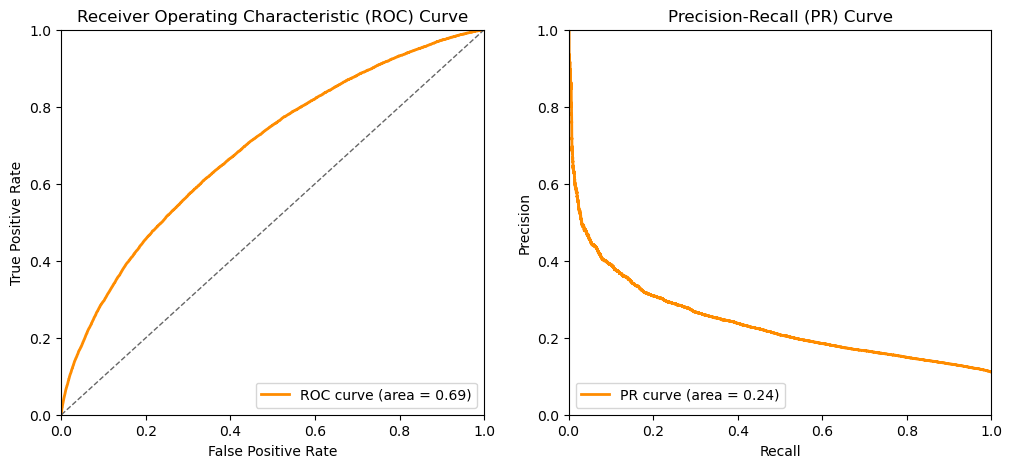

AUROC: 0.6893
AUPRC: 0.2401


In [4]:
ehr_utils.plot_roc_pr_curves(Y_test, Y_pred_proba, model_name='xgb_model')

In [ ]:

xxx=[1,2,3]
yyy=[1,0,0]
zzz=[1,1,1]
x1,x2,x3,x4,x5,x6 = train_test_split(xxx,yyy,zzz, train_size=0.8, random_state=42)
print(x1,x2,x3,x4,x5,x6)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from ehr_utils import plot_roc_pr_curves
# 生成模拟数据
X, y = make_classification(n_samples=120, n_features=20, n_classes=2, random_state=42)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 训练模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 获取模型预测的概率
y_pred_proba = model.predict_proba(X_test)[:, 1]

plot_roc_pr_curves(y_test,y_pred_proba)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
n = 10000
mean = [0, 0]
cov = [(2, .4), (.4, .2)]
rng = np.random.RandomState(0)
x, y = rng.multivariate_normal(mean, cov, n).T

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)